In [1]:
%pip install -q torchmetrics
import torch
if torch.cuda.is_available():
    device='cuda'
else:
    device = 'cpu'
device

'cuda'

In [2]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images

sample_images = np.stack(load_sample_images()['images'])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

In [5]:
sample_images.shape

torch.Size([2, 427, 640, 3])

In [33]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

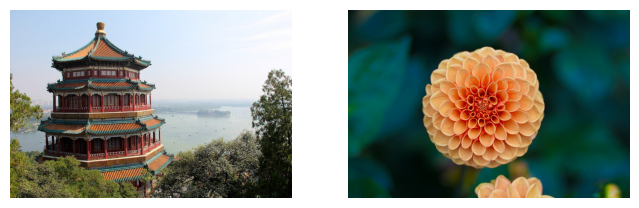

In [7]:
import matplotlib.pyplot as plt
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

In [8]:
import torchvision
import torchvision.transforms.v2 as T
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

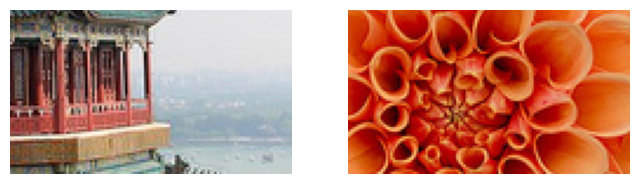

In [7]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [9]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32,kernel_size=7)
fmaps= conv_layer(cropped_images)

In [10]:
fmaps.shape

torch.Size([2, 32, 64, 114])

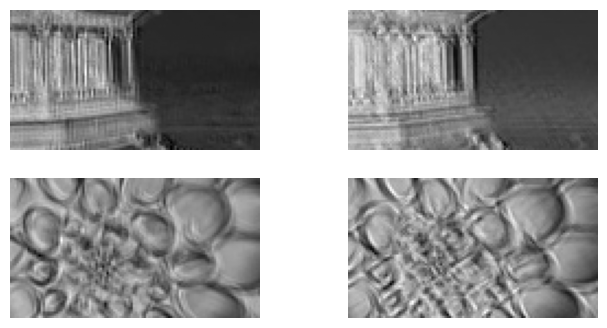

In [10]:
# extra code – displays the two output feature maps for each image

plt.figure(figsize=(8, 4))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap="gray")
        plt.axis("off")

plt.show()

In [11]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7,
                       padding='same')
fmaps = conv_layer(cropped_images)

In [8]:
fmaps.shape

torch.Size([2, 32, 70, 120])

In [12]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2,
                       padding=3)
fmaps= conv_layer(cropped_images)
fmaps.shape

torch.Size([2, 32, 35, 60])

In [13]:
conv_layer.weight.shape

torch.Size([32, 3, 7, 7])

In [11]:
conv_layer.bias.shape

torch.Size([32])

In [14]:
import torch.nn.functional as F

torch.manual_seed(42)
filters = torch.randn([2, 3, 7, 7])
biases = torch.zeros([2])
fmaps = F.conv2d(cropped_images, filters, biases, stride=1, padding="same")

In [13]:
fmaps.shape

torch.Size([2, 2, 70, 120])

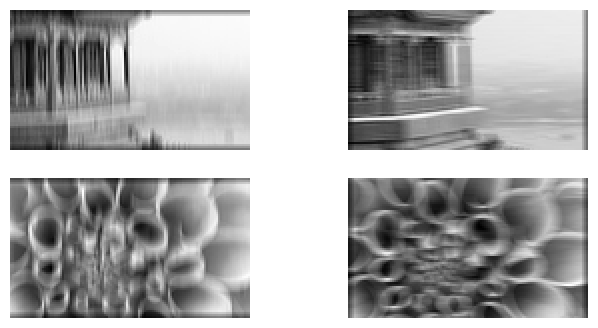

In [18]:
# extra code – shows how to manually create two filters to get images similar
#              to those in Figure 12–5.

plt.figure(figsize=(8, 4))
filters = torch.zeros([2, 3, 7, 7])
filters[0, :, :, 3] = 1
filters[1, :, 3, :] = 1
fmaps = F.conv2d(cropped_images, filters, biases, stride=1, padding="same")

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

In [14]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [15]:
output_max = max_pool(cropped_images)

In [16]:
avg_pool = nn.AvgPool2d(kernel_size=2)

In [17]:
output_avg = avg_pool(cropped_images)

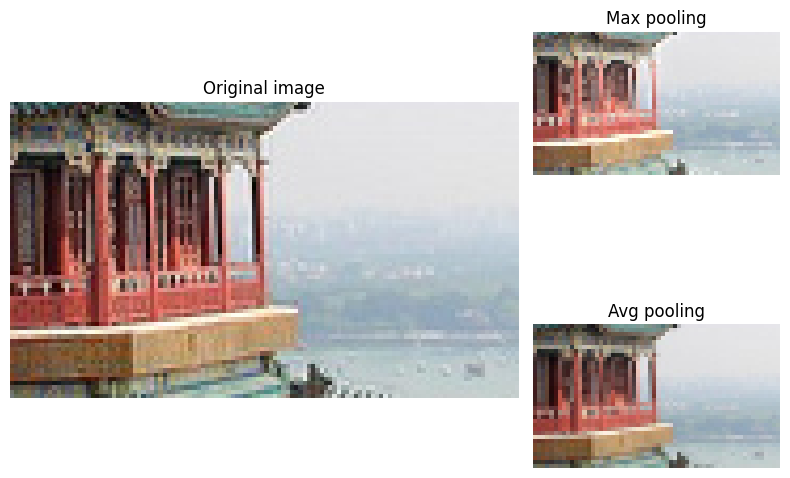

In [23]:

fig = plt.figure(figsize=(8, 6))

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(cropped_images[0].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title("Original image")

ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.imshow(output_max[0].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title("Max pooling")

ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[0].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()


In [15]:
import torch.nn.functional as F

class DepthMaxPool2(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding
    
    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        Z = inputs.view(batch, channels, height * width)
        Z = Z.permute(0, 2, 1)
        Z = F.maz_pool1d(Z, kernel_size = self.kernel_size, stride=self.stride,
                         padding=self.padding)
        Z = Z.permute(0,2,1)
        return Z.view(batch, -1, height, width)

In [19]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))

In [20]:
output = global_avg_pool(cropped_images)

In [21]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)

In [22]:
output = global_avg_pool(cropped_images)

In [23]:
output = cropped_images.mean(dim=(2,3), keepdim=True)

In [16]:
from functools import partial

torch.manual_seed(42)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding='same')
model = nn.Sequential(
    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [17]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [18]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

In [19]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [41]:
n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.9941, train metric: 0.6205, valid metric: 0.8016
Epoch 2/20, train loss: 0.5741, train metric: 0.7877, valid metric: 0.8280
Epoch 3/20, train loss: 0.4974, train metric: 0.8185, valid metric: 0.8616
Epoch 4/20, train loss: 0.4418, train metric: 0.8468, valid metric: 0.8668
Epoch 5/20, train loss: 0.4032, train metric: 0.8626, valid metric: 0.8752
Epoch 6/20, train loss: 0.3760, train metric: 0.8717, valid metric: 0.8890
Epoch 7/20, train loss: 0.3580, train metric: 0.8779, valid metric: 0.8884
Epoch 8/20, train loss: 0.3370, train metric: 0.8870, valid metric: 0.8876
Epoch 9/20, train loss: 0.3257, train metric: 0.8901, valid metric: 0.8956
Epoch 10/20, train loss: 0.3090, train metric: 0.8945, valid metric: 0.8942
Epoch 11/20, train loss: 0.2978, train metric: 0.8989, valid metric: 0.9010
Epoch 12/20, train loss: 0.2843, train metric: 0.9041, valid metric: 0.9006
Epoch 13/20, train loss: 0.2838, train metric: 0.9031, valid metric: 0.8964
Epoch 14/20, train lo

In [20]:
class SeperableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1,
                 padding=0):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride=stride,
            padding=padding, groups=in_channels)
        self.pointwise_conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, stride=1, padding=0)
    
    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))

In [21]:
class ResidualUnit(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        DefaultConv2d = partial(
            nn.Conv2d, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.main_layers = nn.Sequential(
            DefaultConv2d(in_channels, out_channels, stride=stride),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            DefaultConv2d(out_channels, out_channels),
            nn.BatchNorm2d(out_channels),
        )
        if stride > 1:
            self.skip_connection = nn.Sequential(
                DefaultConv2d(in_channels, out_channels, kernel_size=1,
                              stride=stride, padding=0),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip_connection = nn.Identity()
    
    def forward(self, inputs):
        return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

In [22]:
class Resnet34(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7,stride=2,
                      padding=3, bias=False),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        ]
        prev_filters = 64
        for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
            stride = 1 if filters == prev_filters else 2
            layers.append(ResidualUnit(prev_filters, filters, stride=stride))
            prev_filters = filters
        layers += [
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.LazyLinear(10)
        ]
        self.resnet = nn.Sequential(*layers)
    
    def forward(self, inputs):
        return self.resnet(inputs)

In [23]:
torch.manual_seed(42)
model = Resnet34().to(device)
images = torch.randn(2, 3, 224, 224).to(device)
model(images)

tensor([[ 0.2233, -1.0281,  0.8846,  0.5195,  0.1329, -0.0356,  0.0158,  0.2011,
          1.3775,  0.3885],
        [ 0.2202, -1.0636,  1.1203,  0.5913,  0.0325, -0.1761,  0.0831,  0.0497,
          1.7335,  0.7540]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [24]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 208MB/s] 


In [25]:
torch.hub.get_dir()

'/root/.cache/torch/hub'

In [26]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [34]:
list(torchvision.models.get_model_weights("convnext_base"))

[ConvNeXt_Base_Weights.IMAGENET1K_V1]

In [35]:
transforms = weights.transforms()
preprocessed_images = transforms(sample_images_permuted)

In [37]:
model.eval()
with torch.no_grad():
    y_logits = model(preprocessed_images.to(device))

In [38]:
y_logits

tensor([[ 0.9411, -0.3203, -0.3067,  ...,  0.2111,  0.4626, -0.2570],
        [-0.6901, -0.6672, -0.8607,  ...,  0.9288,  4.1106, -0.8371]],
       device='cuda:0')

In [39]:
y_pred = torch.argmax(y_logits, dim=1)
y_pred

tensor([698, 985], device='cuda:0')

In [40]:
weights.meta.keys()

dict_keys(['min_size', 'categories', 'recipe', '_docs', 'num_params', '_metrics', '_ops', '_file_size'])

In [41]:
class_names = weights.meta['categories']
[class_names[class_id] for class_id in y_pred]

['palace', 'daisy']

In [43]:
y_top3_logits, y_top3_class_ids = y_logits.topk(k=3, dim=1)
[[class_names[class_id] for class_id in top3] for top3 in y_top3_class_ids]

[['palace', 'monastery', 'lakeside'], ['daisy', 'pot', 'ant']]

In [44]:
y_top3_logits.softmax(dim=1)

tensor([[0.8618, 0.1185, 0.0197],
        [0.8106, 0.0964, 0.0930]], device='cuda:0')

In [46]:
DefaultFlowers102 = partial(torchvision.datasets.Flowers102, root='datasets',
                            transform = weights.transforms(), download=True)
train_set = DefaultFlowers102(split='train')
valid_set = DefaultFlowers102(split='val')
test_set = DefaultFlowers102(split='test')

100%|██████████| 345M/345M [00:13<00:00, 26.5MB/s] 
100%|██████████| 502/502 [00:00<00:00, 1.99MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 50.3MB/s]


In [47]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [48]:
class_names = ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily']

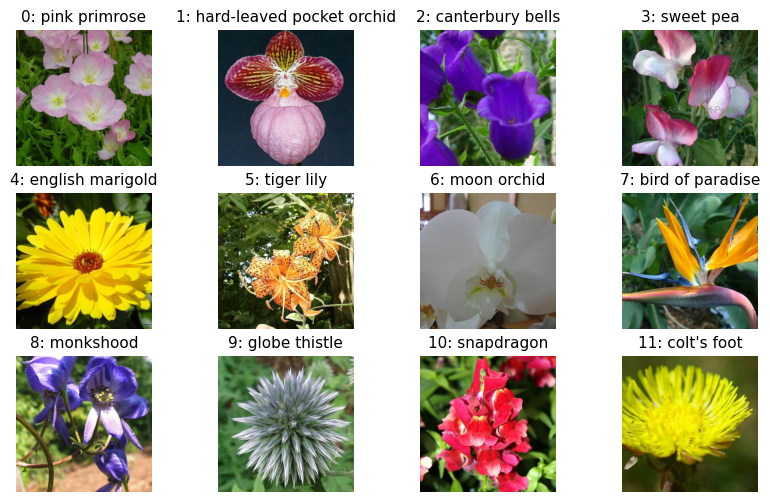

In [49]:
# extra code – displays the 1st image of classes 0 to 11 in the train set

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])
flowers_to_display = DefaultFlowers102(split="train", transform=transform)
sample_flowers = sorted({y: img for img, y in flowers_to_display}.items())[:12]

plt.figure(figsize=(10, 6))
for class_id, image in sample_flowers:
    if class_id == 12: break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [51]:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [54]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [55]:
n_classes = 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

In [56]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [57]:
n_epochs = 5
optimizer= torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task='multiclass',
                                 num_classes=102).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 4.2828, train metric: 0.1422, valid metric: 0.6206
Epoch 2/5, train loss: 3.0120, train metric: 0.6667, valid metric: 0.7725
Epoch 3/5, train loss: 2.0645, train metric: 0.8520, valid metric: 0.8314
Epoch 4/5, train loss: 1.3685, train metric: 0.9206, valid metric: 0.8559
Epoch 5/5, train loss: 0.9400, train metric: 0.9441, valid metric: 0.8667


In [58]:
history = train(model, optimizer, xentropy, accuracy, 
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.6781, train metric: 0.9539, valid metric: 0.8804
Epoch 2/5, train loss: 0.5177, train metric: 0.9627, valid metric: 0.8873
Epoch 3/5, train loss: 0.3888, train metric: 0.9775, valid metric: 0.8980
Epoch 4/5, train loss: 0.3104, train metric: 0.9882, valid metric: 0.8980
Epoch 5/5, train loss: 0.2463, train metric: 0.9892, valid metric: 0.8912


In [59]:
for param in model.parameters():
    param.requires_grad = True

In [60]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.6871, train metric: 0.8294, valid metric: 0.8186
Epoch 2/5, train loss: 0.2714, train metric: 0.9245, valid metric: 0.8549
Epoch 3/5, train loss: 0.1438, train metric: 0.9598, valid metric: 0.7853
Epoch 4/5, train loss: 0.1595, train metric: 0.9529, valid metric: 0.8020
Epoch 5/5, train loss: 0.1627, train metric: 0.9490, valid metric: 0.8118


In [61]:
import torchvision.transforms.v2 as T

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
